<h1><center>Churn Prediction (Statistical Testing, Stacking Ensemble) </center></h1>

<center><img src="https://uploads-ssl.webflow.com/60d45d63543dd9baaad4cb28/60d85fd90743e2299c711be5_1%20dqSLRSEC2GDV9bw_PplCYQ.png" align="center"/></center>

<a id='9'></a>
# 9 Data Preparation

<a id='9.1'></a>
## 9.1 Prepare Train/Test dataset

In [94]:
strat_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
for train_index, test_index in strat_split.split(df_churn_cleaned, df_churn_cleaned["Churn"]):
    strat_train_set = df_churn_cleaned.loc[train_index]
    strat_test_set = df_churn_cleaned.loc[test_index]

print('Target Labels Ratio in Original Dataset\n')
print(df_churn_cleaned["Churn"].value_counts(normalize=True).sort_index())
# df_churn_cleaned["Churn"].value_counts() / len(strat_test_set)

print('\nTarget Labels Ratio in Test Dataset\n')
print(strat_test_set["Churn"].value_counts(normalize=True).sort_index())
# strat_test_set["Churn"].value_counts() / len(strat_test_set)

Target Labels Ratio in Original Dataset

Churn
0.0    0.73463
1.0    0.26537
Name: proportion, dtype: float64

Target Labels Ratio in Test Dataset

Churn
0.0    0.734564
1.0    0.265436
Name: proportion, dtype: float64


In [95]:
# train Dataset
X = strat_train_set.drop("Churn", axis=1)
y = strat_train_set["Churn"].copy()

# test dataset
y_test = strat_test_set['Churn'].values
X_test = strat_test_set.drop('Churn',axis=1)

X.shape, y.shape, X_test.shape, y_test.shape

((5634, 22), (5634,), (1409, 22), (1409,))

In [96]:
# Check cardinality of categorical variables : 

# reinitiate cat_cols because 'customerID' is still included in cat_cols variable
cat_cols = list(set(X.columns) - set(X._get_numeric_data().columns))
num_cols = list(set(X._get_numeric_data().columns) - set({'SeniorCitizen'})) # already converted
# Get number of unique entries in each column with categorical data
object_nunique = list(map(lambda col: X[col].nunique(), cat_cols))
d = dict(zip(cat_cols, object_nunique))

print("Number of unique entries by column, in ascending order:\n")
pprint.pprint(sorted(d.items(), key=lambda x: x[1]))

print("Total Categorical Columns",len(cat_cols))
print("Total Numerical Columns",len(num_cols))

printmd("**<br>Dataset has maximum cardinality value of 4 which is comparatively low<br>**")

Number of unique entries by column, in ascending order:

[('PhoneService', 2),
 ('PaperlessBilling', 2),
 ('gender', 2),
 ('Partner', 2),
 ('Dependents', 2),
 ('MultipleLines', 3),
 ('OnlineSecurity', 3),
 ('StreamingMovies', 3),
 ('MonthlyCharges-binned', 3),
 ('TotalCharges-binned', 3),
 ('DeviceProtection', 3),
 ('StreamingTV', 3),
 ('OnlineBackup', 3),
 ('Contract', 3),
 ('TechSupport', 3),
 ('tenure-binned', 3),
 ('InternetService', 3),
 ('PaymentMethod', 4)]
Total Categorical Columns 18
Total Numerical Columns 3


**<br>Dataset has maximum cardinality value of 4 which is comparatively low<br>**

<a id='9.2'></a>
## 9.2 Encoding & Scaling

In [97]:
ordinal_encoder = OrdinalEncoder()
X[cat_cols] = ordinal_encoder.fit_transform(X[cat_cols])
X_test[cat_cols] = ordinal_encoder.transform(X_test[cat_cols])

le = LabelEncoder()
y = le.fit_transform(y)

y_test = le.fit_transform(y_test)


num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

transformer = RobustScaler()
X[num_cols] = transformer.fit_transform(X[num_cols])
X_test[num_cols] = transformer.transform(X_test[num_cols])

**Correlation Heatmap**

**Pearson’s R** (parametric) is not applicable when the data is categorical

Kendall’s Tau is a non-parametric measure of relationships between continuous or ordinal features

While Pearson's correlation assesses linear relationships, **Spearman's correlation** (non -parametric) assesses monotonic relationships (whether linear or not)

Most of the features in this dataset are categorical and nominal, so it's ineffective for those non-numerical attributes

Moreover, there are only three numerical features which are not normally distributed

Therefore, **pandas.corr() is not feasible to use for this case**

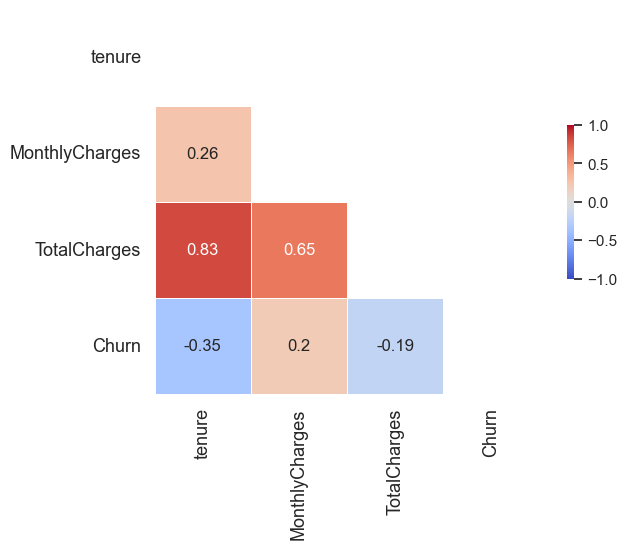

**Tenure is moderately correlated Numerical Feature with Target**

In [98]:
# Correlation Matrix
# only numerical output
corr_matrix = pd.concat([X[num_cols],strat_train_set[["Churn"]]],axis=1).corr()

# Set Up Mask To Hide Upper Triangle
mask = np.zeros_like(corr_matrix, dtype=np.bool)
mask[np.triu_indices_from(mask)]= True

with sns.axes_style("white"):
    f, ax = plt.subplots(figsize=(7, 5))
    ax = sns.heatmap(corr_matrix,
                      mask = mask,
                      square = True,
                      linewidths = .5,
                      cmap = 'coolwarm',
                      cbar_kws = {'shrink': .4,
                                'ticks' : [-1, -.5, 0, 0.5, 1]},
                      vmin = -1,
                      vmax = 1,
                      annot = True,
                      annot_kws = {'size': 12})

#add the column names as labels
ax.set_yticklabels(corr_matrix.columns, rotation = 0, fontsize=13)
ax.set_xticklabels(corr_matrix.columns, fontsize=13)

sns.set_style({'xtick.bottom': True}, {'ytick.left': True})
plt.show()

printmd("**Tenure is moderately correlated Numerical Feature with Target**")